# Coherence Score Analysis - Greenwashing Subset (Google Colab)

This notebook computes gensim c_v coherence scores for the greenwashing subset
(df_greenwashing_topic1.csv) to select the optimal number of LDA topics.
Run on Google Colab (Python 3.12) due to gensim compatibility issues with Python 3.14+.

In [ ]:
import pandas as pd
import numpy as np
import gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()  # si apre un file picker, selezioni il csv

Saving df_greenwashing_topic1.csv to df_greenwashing_topic1.csv


In [3]:
df = pd.read_csv('df_greenwashing_topic1.csv')
df['text_clean'] = df['text_clean'].fillna('')

In [4]:
# prepare texts in gensim format
texts = [text.split() for text in df['text_clean']]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")

Vocabulary size: 14637
Corpus size: 3602


n_topics=2: coherence=0.4996
n_topics=3: coherence=0.4519
n_topics=4: coherence=0.4684
n_topics=5: coherence=0.4390
n_topics=6: coherence=0.3775
n_topics=7: coherence=0.4162
n_topics=8: coherence=0.4364


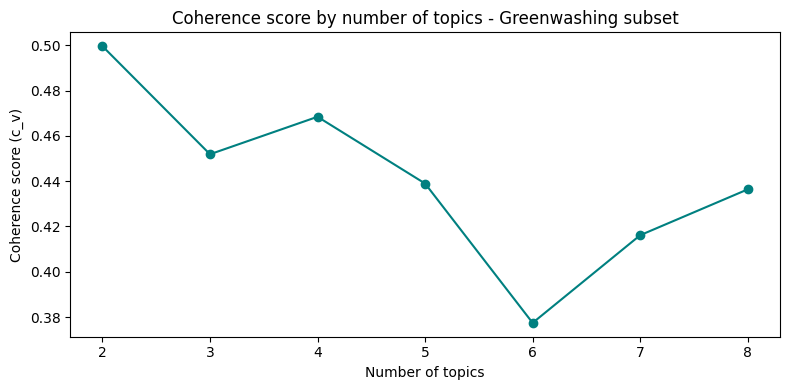

In [5]:
import matplotlib.pyplot as plt

coherence_scores = []
n_topics_range = range(2, 9)

for n in n_topics_range:
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n,
        random_state=42,
        passes=10
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"n_topics={n}: coherence={score:.4f}")

# plot
plt.figure(figsize=(8, 4))
plt.plot(n_topics_range, coherence_scores, marker='o', color='teal')
plt.xlabel('Number of topics')
plt.ylabel('Coherence score (c_v)')
plt.title('Coherence score by number of topics - Greenwashing subset')
plt.tight_layout()
plt.show()